In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
import SimpleITK as sitk

def hex_to_RGB(hex_str):
    """ #FFFFFF -> [255,255,255]"""
    #Pass 16 to the integer function for change of base
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):
    """
    Given two hex colors, returns a color gradient
    with n colors.
    """
    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]

def violinplot_with_mean_line(x, data, ax, palette, zorder):
    violin_parts = ax.violinplot(data, positions=x, showmeans=False, showmedians=False, showextrema=False, points=50)
    for i, pc in enumerate(violin_parts['bodies']):
        pc.set_facecolor(palette[i])
        pc.set_edgecolor('black')
        pc.set_alpha(1)
        mean_val = np.mean(data[i])
        ax.plot([i-0.15, i+0.15], [mean_val, mean_val], color='black', linestyle='-', linewidth=.8, zorder=zorder)
    return violin_parts

In [2]:
import pickle
import json
import torch
# from tqdm import tqdm
from segment_anything import sam_model_registry
from eval_bbox_regression import upsampled_vote, bbox_vote_infer
from utils import majority_voting, resize2origin
from metrics import compute_dice_coefficient
import SimpleITK as sitk
import numpy as np
import os
task = 'MRI_LeftKidney_3views_label'
num_samples = 40
bseed = 2024
sseed = 2024
sam_checkpoint = 'checkpoints/SAM/sam_vit_b_01ec64.pth'
medsam_checkpoint = 'checkpoints/MedSAM/medsam_vit_b.pth'
mask_vote = True
pred_vote = True
mode = 'test'

bbox_model = pickle.load(open('checkpoints/medsam_norm_bbox_regression/MRI_LeftKidney_3views_label_40samples_seed2024.pkl','rb'))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with open(f'datasets/RAINE_organ_51/MRI_LeftKidney/{mode}/sub_index.json', 'r') as f:
    sub_index = json.load(f)
id_set = sorted([k.split('.')[0] for k in sub_index.keys()])

sam_model = sam_model_registry['vit_b'](checkpoint=medsam_checkpoint).to(device)
sam_model.eval()

dices_final = []
dices_axial = []
dices_sagittal = []
dices_coronal = []
i = 0
id = id_set[i]
# print(id)
original_img = sitk.ReadImage(f'datasets/RAINE_organ_51/trainingset_51/{id}.FatImaging_W.nii.gz')
original_imgarray = sitk.GetArrayFromImage(original_img)
original_gtarray = sitk.GetArrayFromImage(sitk.ReadImage(f'datasets/RAINE_organ_51/trainingset_51/labels/final/{id}.FatImaging_W.nii.gz'))
original_gtarray = np.uint8(original_gtarray==1)
original_shape = original_gtarray.shape
views = ['medsam_MRI_LeftKidney_axial_norm_all', 'medsam_MRI_LeftKidney_sagittal_norm_all', 'medsam_MRI_LeftKidney_coronal_norm_all']
image_size = 256
bbox_shift = 20
if mask_vote:
    # if os.path.exists(os.path.join('datasets/vote_mask_preds_nature_medsam_all/', f'{id}_3views_{num_samples}samples_seed{sseed}.npy')):
    #     vote_mask_preds = np.load(os.path.join('datasets/vote_mask_preds_nature_medsam_all/', f'{id}_3views_{num_samples}samples_seed{sseed}.npy'))
    # else:
    vote_mask_preds = upsampled_vote(bbox_model, i, mode, views, original_shape, mask_vote)
        # np.save(os.path.join('datasets/vote_mask_preds_nature_medsam_all/', f'{id}_3views_{num_samples}samples_seed{sseed}.npy'), vote_mask_preds)
    
    # clean mask from axial view to remove the right kidney
    for slice in vote_mask_preds:
        index = slice.shape[1] //2  
        slice[:,0:index] = 0

    preds_axial, bboxes_axial, imgs_axial, gts_axial = bbox_vote_infer(vote_mask_preds, views[0],mode, i, sam_model, device,bseed,image_size,bbox_shift)
    dice_axial = compute_dice_coefficient(gts_axial, preds_axial)
    dices_axial.append(dice_axial)

    preds_sagittal, bboxes_sagittal, imgs_sagittal, gts_sagittal = bbox_vote_infer(vote_mask_preds, views[1],mode, i, sam_model, device,bseed,image_size, bbox_shift)
    dice_sagittal = compute_dice_coefficient(gts_sagittal, preds_sagittal)
    dices_sagittal.append(dice_sagittal)

    preds_coronal, bboxes_coronal, imgs_coronal, gts_coronal = bbox_vote_infer(vote_mask_preds, views[2],mode, i, sam_model, device,bseed,image_size,bbox_shift)
    dice_coronal = compute_dice_coefficient(gts_coronal, preds_coronal)
    dices_coronal.append(dice_coronal)
else:
    mask_preds_axial_ori, mask_preds_sagittal_ori, mask_preds_coronal_ori = upsampled_vote(bbox_model, i,mode, views, original_shape,mask_vote)
    preds_axial, bboxes_axial, imgs_axial, gts_axial = bbox_vote_infer(mask_preds_axial_ori, views[0],mode, i, sam_model, device,bseed,image_size,bbox_shift)
    dice_axial = compute_dice_coefficient(gts_axial, preds_axial)
    dices_axial.append(dice_axial)

    preds_sagittal, bboxes_sagittal, imgs_sagittal, gts_sagittal = bbox_vote_infer(mask_preds_sagittal_ori, views[1],mode, i, sam_model, device,bseed,image_size,bbox_shift)
    dice_sagittal = compute_dice_coefficient(gts_sagittal, preds_sagittal)
    dices_sagittal.append(dice_sagittal)

    preds_coronal, bboxes_coronal, imgs_coronal, gts_coronal = bbox_vote_infer(mask_preds_coronal_ori, views[2],mode, i, sam_model, device, bseed,image_size,bbox_shift)
    dice_coronal = compute_dice_coefficient(gts_coronal, preds_coronal)
    dices_coronal.append(dice_coronal)

pred_axial_ori, pred_sagittal_ori, pred_coronal_ori = resize2origin(preds_axial, preds_sagittal, preds_coronal, views, original_shape,mode, id)
if pred_vote:
    pred_final = majority_voting(pred_axial_ori, pred_sagittal_ori, pred_coronal_ori)
    dice_final = compute_dice_coefficient(original_gtarray, pred_final)
    dices_final.append(dice_final)

#         np.save(os.path.join(output_dir, f'{mode}_vote_upsampled_3views_emb_bseed{bseed}_sample{num_samples}_sseed{sseed}.npy'), dices_final)   
# np.save(os.path.join(output_dir, f'{mode}_vote_upsampled_axial_emb_bseed{bseed}_sample{num_samples}_sseed{sseed}.npy'), dices_axial)
# np.save(os.path.join(output_dir, f'{mode}_vote_upsampled_sagittal_emb_bseed{bseed}_sample{num_samples}_sseed{sseed}.npy'), dices_sagittal)
# np.save(os.path.join(output_dir, f'{mode}_vote_upsampled_coronal_emb_bseed{bseed}_sample{num_samples}_sseed{sseed}.npy'), dices_coronal)



sub-10100 Voting time: 18.13223624229431


In [3]:
dice_final, dice_axial, dice_sagittal, dice_coronal

(0.7527020855533567, 0.705690440060698, 0.650110575354385, 0.7396224944971463)

In [4]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([251 / 255, 252 / 255, 30 / 255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

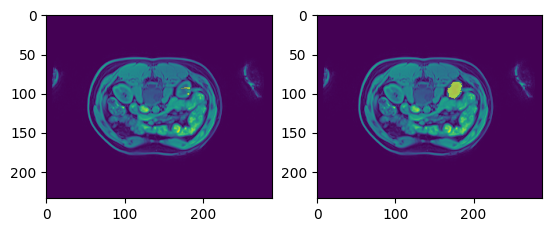

In [5]:
from utils import show_box
fig,ax = plt.subplots(1,2)
i = 66
ax[0].imshow(original_imgarray[i])
show_mask(vote_mask_preds[i], ax[0])
# ax[0].imshow(vote_mask_preds[i],alpha=0.5)
# show_box(bboxes_axial[i], ax[0])
ax[1].imshow(original_imgarray[i])
show_mask(original_gtarray[i], ax[1])
# ax[1].imshow(original_gtarray[i],alpha=0.5)

Text(0.5, 0.98, 'ID: sub-10100 Dice: 0.75')

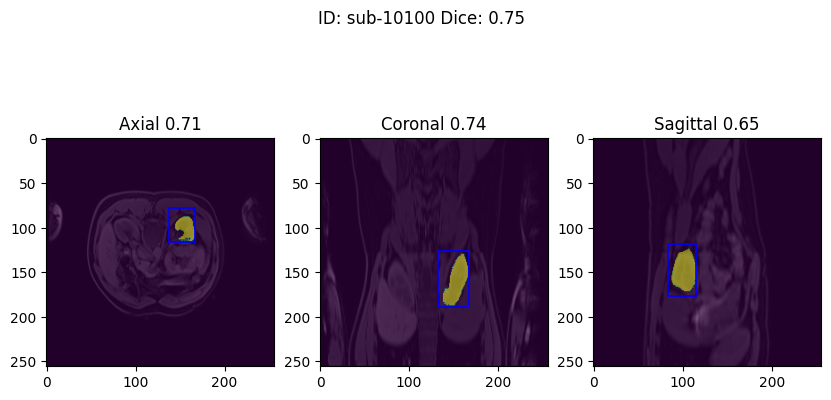

In [6]:
from utils import show_box
dices_final
fig, ax = plt.subplots(1,3, figsize=(10, 5))
# x = 66
ax[0].imshow(imgs_axial[77,:,:], cmap='gray') # 66, 88, 180
ax[0].imshow(preds_axial[77,:,:], alpha=0.5)
show_box(bboxes_axial[77], ax[0])
# ax[0].axis('off')
ax[0].set_title(f'Axial {dice_axial:.2f}')
ax[1].imshow(imgs_coronal[88,:,:], cmap='gray') # 66, 88, 180
ax[1].imshow(preds_coronal[88,:,:], alpha=0.5)
show_box(bboxes_coronal[88], ax[1])
# ax[1].axis('off')
ax[1].set_title(f'Coronal {dice_coronal:.2f}')
ax[2].imshow(imgs_sagittal[180,:,:], cmap='gray') # 66, 88, 180
ax[2].imshow(preds_sagittal[180,:,:], alpha=0.5)
show_box(bboxes_sagittal[180], ax[2])
# ax[2].axis('off')
ax[2].set_title(f'Sagittal {dice_sagittal:.2f}')


plt.suptitle(f'ID: {id} Dice: {dice_final:.2f}')


Text(0.5, 0.98, 'ID: sub-10100 Dice: 0.75')

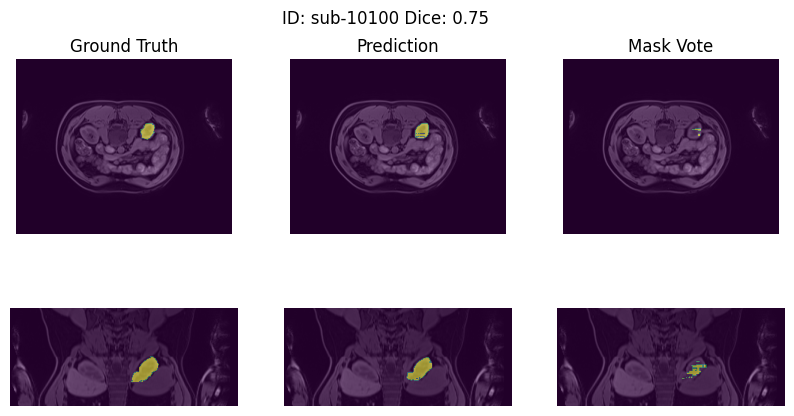

In [7]:
dices_final
fig, ax = plt.subplots(2,3, figsize=(10, 5))
x = 66
ax[0,0].imshow(original_imgarray[x,:,:], cmap='gray') # 66, 88, 180
ax[0,0].imshow(original_gtarray[x,:,:], alpha=0.5)
ax[0,0].axis('off')
ax[0,0].set_title('Ground Truth')
ax[0,1].imshow(original_imgarray[x,:,:], cmap='gray') # 66, 88, 180
ax[0,1].imshow(pred_final[x,:,:], alpha=0.5)
ax[0,1].axis('off')
ax[0,1].set_title('Prediction')
ax[0,2].imshow(original_imgarray[x,:,:], cmap='gray') # 66, 88, 180
ax[0,2].imshow(vote_mask_preds[x,:,:], alpha=0.5)
ax[0,2].axis('off')
ax[0,2].set_title('Mask Vote')

index = 88
ax[1,0].imshow(original_imgarray[:,index,:], cmap='gray')
ax[1,0].imshow(original_gtarray[:,index,:], alpha=0.5)
ax[1,0].axis('off')
ax[1,1].imshow(original_imgarray[:,index,:], cmap='gray')
ax[1,1].imshow(pred_final[:,index,:], alpha=0.5)
ax[1,1].axis('off')
ax[1,2].imshow(original_imgarray[:,index,:], cmap='gray')
ax[1,2].imshow(vote_mask_preds[:,index,:], alpha=0.5)
ax[1,2].axis('off')

plt.suptitle(f'ID: {id} Dice: {dice_final:.2f}')

(-0.5, 287.5, 123.5, -0.5)

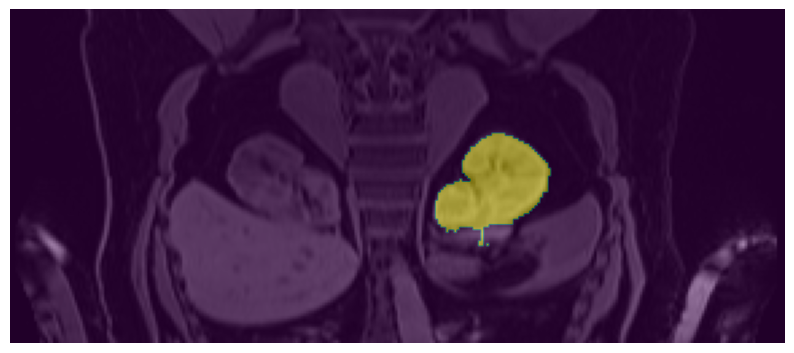

In [139]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
index = 88
ax.imshow(original_imgarray[:,index,:], cmap='gray')
ax.imshow(pred_final[:,index,:], alpha=0.5)
ax.axis('off')

/tmp/ipykernel_691732/305759890.py:22: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data, jitter=True, ax=ax, zorder=1, size=3, linewidth=0.1, color='black',edgecolor='gray')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


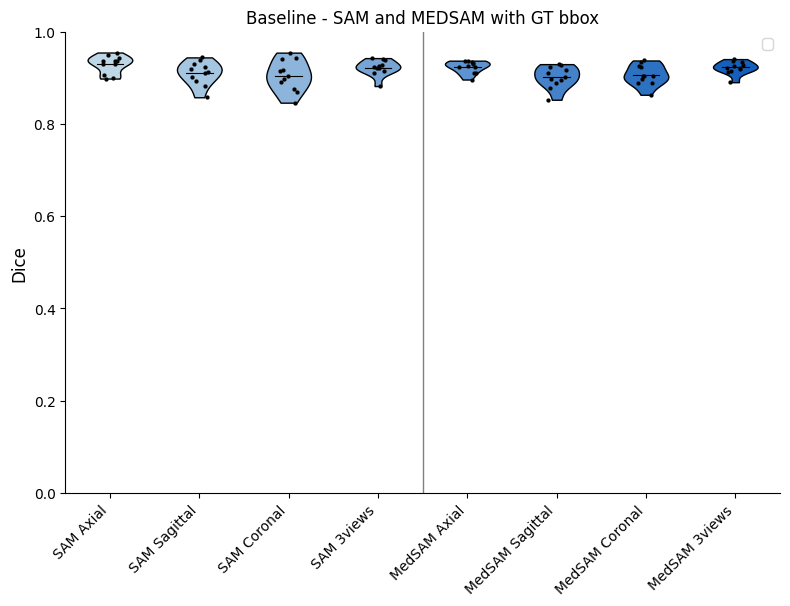

In [2]:
s = 'False'
sam_dice_3views = np.load(f'./results/dice/original/sam_vit_b_roi_testing_3views_seed{s}.npy')
sam_dice_axial = np.load(f'./results/dice/original/sam_vit_b_roi_testing_axial_seed{s}.npy')
sam_dice_coronal = np.load(f'./results/dice/original/sam_vit_b_roi_testing_coronal_seed{s}.npy')
sam_dice_sagittal = np.load(f'./results/dice/original/sam_vit_b_roi_testing_sagittal_seed{s}.npy')

medsam_dice_3views = np.load(f'./results/dice/original_medsam_norm/medsam_vit_b_roi_testing_3views_seed{s}.npy')
medsam_dice_axial = np.load(f'./results/dice/original_medsam_norm/medsam_vit_b_roi_testing_axial_seed{s}.npy')
medsam_dice_coronal = np.load(f'./results/dice/original_medsam_norm/medsam_vit_b_roi_testing_coronal_seed{s}.npy')
medsam_dice_sagittal = np.load(f'./results/dice/original_medsam_norm/medsam_vit_b_roi_testing_sagittal_seed{s}.npy')

x_labels = ['SAM Axial', 'SAM Sagittal', 'SAM Coronal', 'SAM 3views', 'MedSAM Axial', 'MedSAM Sagittal', 'MedSAM Coronal', 'MedSAM 3views']
data = [sam_dice_axial, sam_dice_sagittal, sam_dice_coronal, sam_dice_3views, medsam_dice_axial, medsam_dice_sagittal, medsam_dice_coronal, medsam_dice_3views]

c2 = '#1560bd'
c1 = '#bdd7e7'
colors = get_color_gradient(c1, c2, len(x_labels))
fig, ax = plt.subplots(1,1,figsize=(8,6))
plots = violinplot_with_mean_line(range(len(x_labels)), data, ax, colors, 1)


sns.stripplot(data, jitter=True, ax=ax, zorder=1, size=3, linewidth=0.1, color='black',edgecolor='gray')
ax.axvline(3.5, color='grey', lw=1)

ax.set_ylabel('Dice', fontsize=12)
ax.set_ylim(0, 1)
ax.set_xticks(np.arange(len(x_labels)), labels=x_labels)
# ax.set_xlim(0.25, len(x_labels) + 0.75)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation = 45, fontsize=10,ha='right')
plt.tight_layout()
plt.title('Baseline - SAM and MEDSAM with GT bbox')
plt.ylabel('Dice')
plt.legend()
plt.show()

### All results are calculated on 11 testing subjects

In [24]:
# baseline 1 - SAM gt 20 pixels jitter bbox
sam_dice_3views = []
sam_dice_axial = []
sam_dice_coronal = []
sam_dice_sagittal = []
medsam_dice_3views = []
medsam_dice_axial = []
medsam_dice_coronal = []
medsam_dice_sagittal = []

for s in range(2020, 2025):
    sam_dice_3views.append(np.load(f'./results/dice/original/sam_vit_b_roi_testing_3views_seed{s}.npy'))
    sam_dice_axial.append(np.load(f'./results/dice/original/sam_vit_b_roi_testing_axial_seed{s}.npy'))
    sam_dice_coronal.append(np.load(f'./results/dice/original/sam_vit_b_roi_testing_coronal_seed{s}.npy'))
    sam_dice_sagittal.append(np.load(f'./results/dice/original/sam_vit_b_roi_testing_sagittal_seed{s}.npy'))

    medsam_dice_3views.append(np.load(f'./results/dice/original_medsam/medsam_vit_b_roi_testing_3views_seed{s}.npy'))
    medsam_dice_axial.append(np.load(f'./results/dice/original_medsam/medsam_vit_b_roi_testing_axial_seed{s}.npy'))
    medsam_dice_coronal.append(np.load(f'./results/dice/original_medsam/medsam_vit_b_roi_testing_coronal_seed{s}.npy'))
    medsam_dice_sagittal.append(np.load(f'./results/dice/original_medsam/medsam_vit_b_roi_testing_sagittal_seed{s}.npy'))

sam_dice_3views = np.array(sam_dice_3views)
sam_dice_axial = np.array(sam_dice_axial)
sam_dice_coronal = np.array(sam_dice_coronal)
sam_dice_sagittal = np.array(sam_dice_sagittal)    
medsam_dice_3views = np.array(medsam_dice_3views)
medsam_dice_axial = np.array(medsam_dice_axial)
medsam_dice_coronal = np.array(medsam_dice_coronal)
medsam_dice_sagittal = np.array(medsam_dice_sagittal)   
print(sam_dice_3views.shape, sam_dice_axial.shape, sam_dice_coronal.shape, sam_dice_sagittal.shape)

sam_dice_3views_mean = np.mean(sam_dice_3views, axis=0)
sam_dice_3views_std = np.std(sam_dice_3views, axis=0)
sam_dice_axial_mean = np.mean(sam_dice_axial, axis=0)
sam_dice_axial_std = np.std(sam_dice_axial, axis=0)
sam_dice_coronal_mean = np.mean(sam_dice_coronal, axis=0)
sam_dice_coronal_std = np.std(sam_dice_coronal, axis=0)
sam_dice_sagittal_mean = np.mean(sam_dice_sagittal, axis=0)
sam_dice_sagittal_std = np.std(sam_dice_sagittal, axis=0)
medsam_dice_3views_mean = np.mean(medsam_dice_3views, axis=0)
medsam_dice_3views_std = np.std(medsam_dice_3views, axis=0)
medsam_dice_axial_mean = np.mean(medsam_dice_axial, axis=0)
medsam_dice_axial_std = np.std(medsam_dice_axial, axis=0)
medsam_dice_coronal_mean = np.mean(medsam_dice_coronal, axis=0)
medsam_dice_coronal_std = np.std(medsam_dice_coronal, axis=0)
medsam_dice_sagittal_mean = np.mean(medsam_dice_sagittal, axis=0)
medsam_dice_sagittal_std = np.std(medsam_dice_sagittal, axis=0)
print(sam_dice_3views_mean.shape, sam_dice_axial_mean.shape, sam_dice_coronal_mean.shape, sam_dice_sagittal_mean.shape)

(5, 11) (5, 11) (5, 11) (5, 11)
(11,) (11,) (11,) (11,)


/tmp/ipykernel_85334/1807940318.py:12: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data, jitter=True, ax=ax, zorder=1, size=3, linewidth=0.1, color='black',edgecolor='gray')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


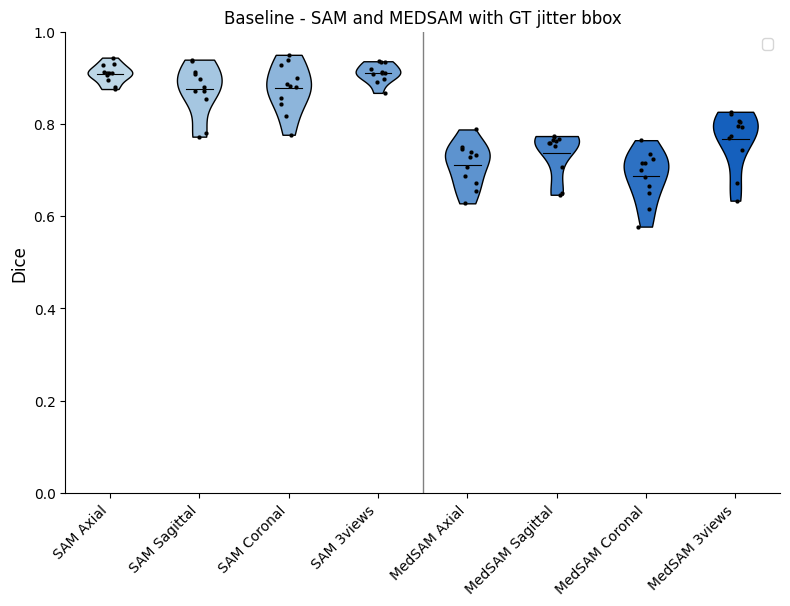

In [30]:
x_labels = ['SAM Axial', 'SAM Sagittal', 'SAM Coronal', 'SAM 3views', 'MedSAM Axial', 'MedSAM Sagittal', 'MedSAM Coronal', 'MedSAM 3views']
seed_index = 4
data = [sam_dice_axial[seed_index], sam_dice_sagittal[seed_index], sam_dice_coronal[seed_index], sam_dice_3views[seed_index], medsam_dice_axial[seed_index], medsam_dice_sagittal[seed_index], medsam_dice_coronal[seed_index], medsam_dice_3views[seed_index]]
# data = [sam_dice_axial_mean, sam_dice_sagittal_mean, sam_dice_coronal_mean, sam_dice_3views_mean, medsam_dice_axial_mean, medsam_dice_sagittal_mean, medsam_dice_coronal_mean, medsam_dice_3views_mean]
c2 = '#1560bd'
c1 = '#bdd7e7'
colors = get_color_gradient(c1, c2, len(x_labels))
fig, ax = plt.subplots(1,1,figsize=(8,6))
plots = violinplot_with_mean_line(range(len(x_labels)), data, ax, colors, 1)


sns.stripplot(data, jitter=True, ax=ax, zorder=1, size=3, linewidth=0.1, color='black',edgecolor='gray')
ax.axvline(3.5, color='grey', lw=1)

ax.set_ylabel('Dice', fontsize=12)
ax.set_ylim(0, 1)
ax.set_xticks(np.arange(len(x_labels)), labels=x_labels)
# ax.set_xlim(0.25, len(x_labels) + 0.75)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation = 45, fontsize=10,ha='right')
plt.tight_layout()
plt.title('Baseline - SAM and MEDSAM with GT jitter bbox')
plt.ylabel('Dice')
plt.legend()
plt.show()

/tmp/ipykernel_3917954/2408039701.py:15: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data, jitter=True, ax=ax, zorder=1, size=5, linewidth=0.1, color='black',edgecolor='gray')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


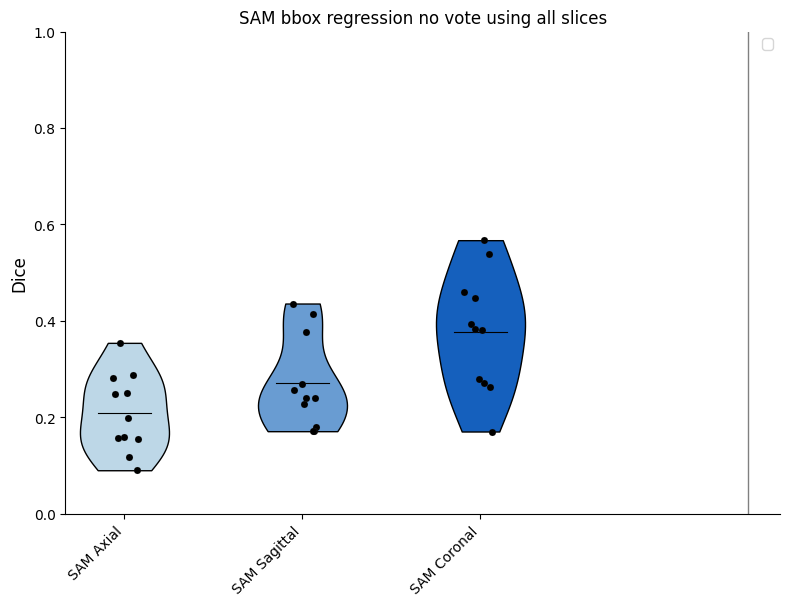

In [7]:
axial_all_dice = np.load('results/dice/bbox_regression_sam_all_novote/test_vote_upsampled_axial_emb_bseed2023_sample40_sseed2024.npy')
sagittal_all_dice = np.load('results/dice/bbox_regression_sam_all_novote/test_vote_upsampled_sagittal_emb_bseed2023_sample40_sseed2024.npy')
coronal_all_dice = np.load('results/dice/bbox_regression_sam_all_novote/test_vote_upsampled_coronal_emb_bseed2023_sample40_sseed2024.npy')
# all_dice = np.load('results/dice/bbox_regression_sam_all/test_vote_upsampled_3views_emb_bseed2023_sample40_sseed2024.npy')

x_labels = ['SAM Axial', 'SAM Sagittal', 'SAM Coronal']
data = [axial_all_dice, sagittal_all_dice, coronal_all_dice]
c2 = '#1560bd'
c1 = '#bdd7e7'
colors = get_color_gradient(c1, c2, len(x_labels))
fig, ax = plt.subplots(1,1,figsize=(8,6))
plots = violinplot_with_mean_line(range(len(x_labels)), data, ax, colors, 1)


sns.stripplot(data, jitter=True, ax=ax, zorder=1, size=5, linewidth=0.1, color='black',edgecolor='gray')
ax.axvline(3.5, color='grey', lw=1)

ax.set_ylabel('Dice', fontsize=12)
ax.set_ylim(0, 1)
ax.set_xticks(np.arange(len(x_labels)), labels=x_labels)
# ax.set_xlim(0.25, len(x_labels) + 0.75)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation = 45, fontsize=10,ha='right')
plt.tight_layout()
plt.title('SAM bbox regression no vote using all slices')
plt.ylabel('Dice')
plt.legend()
plt.show()

In [12]:
bbox_regression_sam_axial_dice = []
bbox_regression_sam_coronal_dice = []
bbox_regression_sam_sagittal_dice = []
bbox_regression_sam_3views_dice = []
dynunet_dice = []
novote_sam_axial_dice = []
novote_sam_coronal_dice = []
novote_sam_sagittal_dice = []

for seed in range(2020,2025):
    seed_bbox_regression_sam_axial_dice = []
    seed_bbox_regression_sam_coronal_dice = []
    seed_bbox_regression_sam_sagittal_dice = []
    seed_bbox_regression_sam_3views_dice = []
    seed_dynunet_dice = []
    seed_novote_sam_axial_dice = []
    seed_novote_sam_coronal_dice = []
    seed_novote_sam_sagittal_dice = []

    for i in range(1,41):
        seed_bbox_regression_sam_axial_dice.append(np.load(f'./results/dice/bbox_regression_sam_all/test_vote_upsampled_axial_emb_bseed2023_sample{i}_sseed{seed}.npy'))
        seed_bbox_regression_sam_coronal_dice.append(np.load(f'./results/dice/bbox_regression_sam_all/test_vote_upsampled_coronal_emb_bseed2023_sample{i}_sseed{seed}.npy'))
        seed_bbox_regression_sam_sagittal_dice.append(np.load(f'./results/dice/bbox_regression_sam_all/test_vote_upsampled_sagittal_emb_bseed2023_sample{i}_sseed{seed}.npy'))
        seed_bbox_regression_sam_3views_dice.append(np.load(f'./results/dice/bbox_regression_sam_all/test_vote_upsampled_3views_emb_bseed2023_sample{i}_sseed{seed}.npy'))
        seed_dynunet_dice.append(np.load(f'./results/dice/epochs100/random_MRI_LeftKidney_DynUNet_epochs100_seed{seed}_test_{i}samples_dice.npy'))
        seed_novote_sam_axial_dice.append(np.load(f'./results/dice/bbox_regression_sam_all_novote/test_vote_upsampled_axial_emb_bseed2023_sample{i}_sseed{seed}.npy'))
        seed_novote_sam_coronal_dice.append(np.load(f'./results/dice/bbox_regression_sam_all_novote/test_vote_upsampled_coronal_emb_bseed2023_sample{i}_sseed{seed}.npy'))
        seed_novote_sam_sagittal_dice.append(np.load(f'./results/dice/bbox_regression_sam_all_novote/test_vote_upsampled_sagittal_emb_bseed2023_sample{i}_sseed{seed}.npy'))

    bbox_regression_sam_axial_dice.append(seed_bbox_regression_sam_axial_dice)
    bbox_regression_sam_coronal_dice.append(seed_bbox_regression_sam_coronal_dice)
    bbox_regression_sam_sagittal_dice.append(seed_bbox_regression_sam_sagittal_dice)
    bbox_regression_sam_3views_dice.append(seed_bbox_regression_sam_3views_dice)
    dynunet_dice.append(seed_dynunet_dice)
    novote_sam_axial_dice.append(seed_novote_sam_axial_dice)
    novote_sam_coronal_dice.append(seed_novote_sam_coronal_dice)
    novote_sam_sagittal_dice.append(seed_novote_sam_sagittal_dice)

bbox_regression_medsam_3views_dice = np.load(f'./results/dice/bbox_regression_nature_medsam_norm_all/test_vote_upsampled_3views_emb_bseed2023_sample40_sseed2024.npy')

bbox_regression_sam_axial_dice = np.array(bbox_regression_sam_axial_dice)
bbox_regression_sam_coronal_dice = np.array(bbox_regression_sam_coronal_dice)
bbox_regression_sam_sagittal_dice = np.array(bbox_regression_sam_sagittal_dice)
bbox_regression_sam_3views_dice = np.array(bbox_regression_sam_3views_dice)
bbox_regression_medsam_3views_dice = np.array(bbox_regression_medsam_3views_dice)
dynunet_dice = np.array(dynunet_dice)
novote_sam_axial_dice = np.array(novote_sam_axial_dice)
novote_sam_coronal_dice = np.array(novote_sam_coronal_dice)
novote_sam_sagittal_dice = np.array(novote_sam_sagittal_dice)


bbox_regression_sam_axial_dice_mean = np.mean(bbox_regression_sam_axial_dice, axis=0)
bbox_regression_sam_coronal_dice_mean = np.mean(bbox_regression_sam_coronal_dice, axis=0)
bbox_regression_sam_sagittal_dice_mean = np.mean(bbox_regression_sam_sagittal_dice, axis=0)
bbox_regression_sam_3views_dice_mean = np.mean(bbox_regression_sam_3views_dice, axis=0)
bbox_regression_medsam_3views_dice_mean = np.mean(bbox_regression_medsam_3views_dice)
dynunet_dice_mean = np.mean(dynunet_dice, axis=0)
novote_sam_axial_dice_mean = np.mean(novote_sam_axial_dice, axis=0)
novote_sam_coronal_dice_mean = np.mean(novote_sam_coronal_dice, axis=0)
novote_sam_sagittal_dice_mean = np.mean(novote_sam_sagittal_dice, axis=0)

In [17]:
bbox_regression_sam_3views_dice.shape, bbox_regression_sam_3views_dice_mean.shape

((5, 40, 11), (40, 11))

In [9]:
avg_bbox_regression_sam_3views_dice_mean = np.mean(bbox_regression_sam_3views_dice_mean, axis=-1)
avg_bbox_regression_sam_3views_dice_std = np.std(bbox_regression_sam_3views_dice_mean, axis=-1)
avg_bbox_regression_sam_axial_dice_mean = np.mean(bbox_regression_sam_axial_dice_mean, axis=-1)
avg_bbox_regression_sam_axial_dice_std = np.std(bbox_regression_sam_axial_dice_mean, axis=-1)
avg_bbox_regression_sam_coronal_dice_mean = np.mean(bbox_regression_sam_coronal_dice_mean, axis=-1)
avg_bbox_regression_sam_coronal_dice_std = np.std(bbox_regression_sam_coronal_dice_mean, axis=-1)
avg_bbox_regression_sam_sagittal_dice_mean = np.mean(bbox_regression_sam_sagittal_dice_mean, axis=-1)
avg_bbox_regression_sam_sagittal_dice_std = np.std(bbox_regression_sam_sagittal_dice_mean, axis=-1)
avg_dynunet_dice_mean = np.mean(dynunet_dice_mean, axis=-1)
avg_dynunet_dice_std = np.std(dynunet_dice_mean, axis=-1)


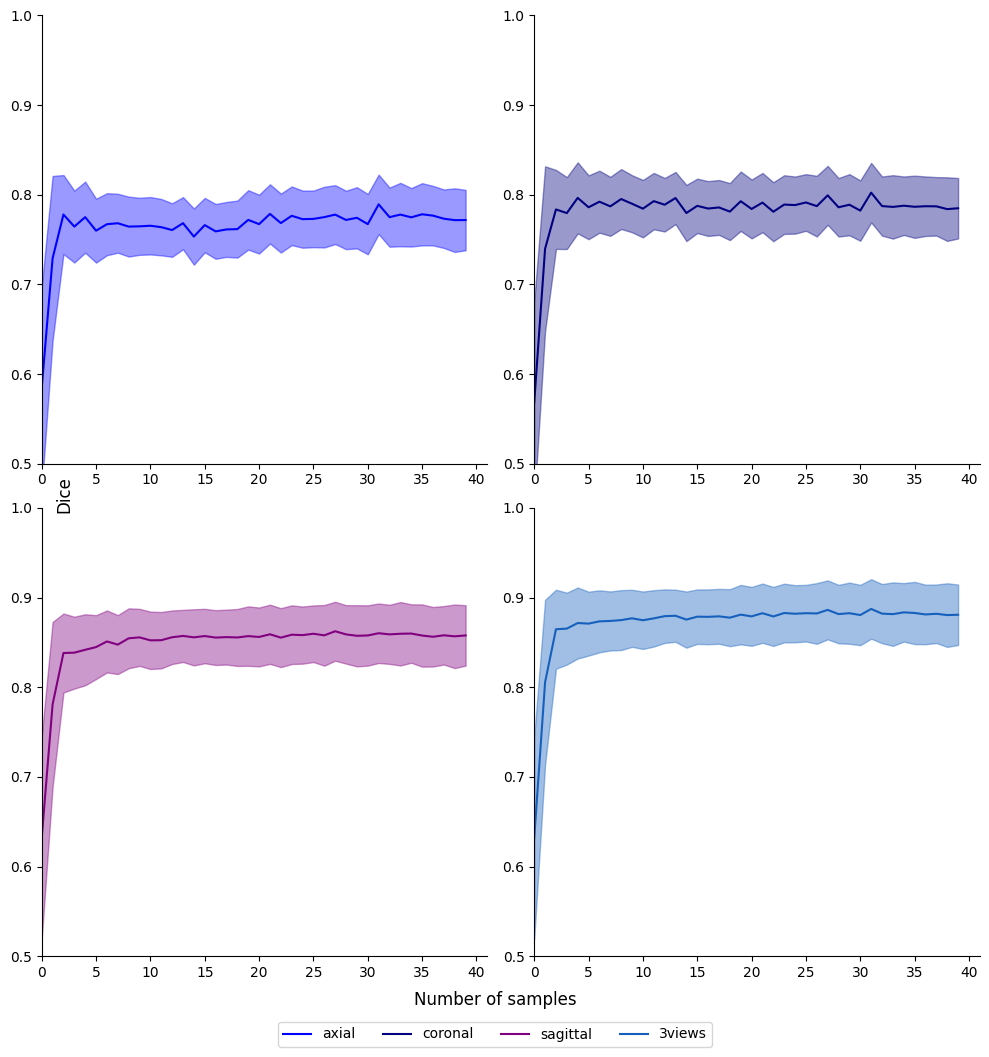

In [251]:
fig, ax = plt.subplots(2,2, figsize=(10,10))
c1 = '#b3cde3'
c2 = '#810f7c'
colors = get_color_gradient(c1, c2, 4)
colors = ['#0000ff', '#000080', '#800080','#1560bd']
ax[0,0].plot(avg_bbox_regression_sam_axial_dice_mean, label='axial', color=colors[0])
ax[0,0].fill_between(range(len(avg_bbox_regression_sam_axial_dice_mean)), avg_bbox_regression_sam_axial_dice_mean-avg_bbox_regression_sam_3views_dice_std, avg_bbox_regression_sam_axial_dice_mean+avg_bbox_regression_sam_3views_dice_std, alpha=0.4, color=colors[0])
# ax[0,0].legend()
ax[0,0].set_ylim(0.5, 1)
ax[0,0].set_xlim(1,41)
ax[0,0].set_xticks(range(0,41,5))
# ax[0,0].set_title('SAM Axial')
ax[0,0].spines['top'].set_visible(False)
ax[0,0].spines['right'].set_visible(False)

ax[0,1].plot(avg_bbox_regression_sam_coronal_dice_mean, label='coronal', color=colors[1])
ax[0,1].fill_between(range(len(avg_bbox_regression_sam_coronal_dice_mean)), avg_bbox_regression_sam_coronal_dice_mean-avg_bbox_regression_sam_3views_dice_std, avg_bbox_regression_sam_coronal_dice_mean+avg_bbox_regression_sam_3views_dice_std, alpha=0.4, color=colors[1])
# ax[0,1].legend()
ax[0,1].set_ylim(0.5, 1)
ax[0,1].set_xlim(1,41)
ax[0,1].set_xticks(range(0,41,5))
ax[0,1].spines['top'].set_visible(False)
ax[0,1].spines['right'].set_visible(False)

ax[1,0].plot(avg_bbox_regression_sam_sagittal_dice_mean, label='sagittal', color=colors[2])
ax[1,0].fill_between(range(len(avg_bbox_regression_sam_sagittal_dice_mean)), avg_bbox_regression_sam_sagittal_dice_mean-avg_bbox_regression_sam_3views_dice_std, avg_bbox_regression_sam_sagittal_dice_mean+avg_bbox_regression_sam_3views_dice_std, alpha=0.4, color=colors[2])
# ax[1,0].legend()
ax[1,0].set_ylim(0.5, 1)
ax[1,0].set_xlim(1,41)
ax[1,0].set_xticks(range(0,41,5))
ax[1,0].spines['top'].set_visible(False)
ax[1,0].spines['right'].set_visible(False)

ax[1,1].plot(avg_bbox_regression_sam_3views_dice_mean, label='3views', color=colors[3])
ax[1,1].fill_between(range(len(avg_bbox_regression_sam_3views_dice_mean)), avg_bbox_regression_sam_3views_dice_mean-avg_bbox_regression_sam_3views_dice_std, avg_bbox_regression_sam_3views_dice_mean+avg_bbox_regression_sam_3views_dice_std, alpha=0.4, color=colors[3])
# ax[1,1].legend()
ax[1,1].set_ylim(0.5, 1)
ax[1,1].set_xlim(1,41)
ax[1,1].set_xticks(range(0,41,5))
ax[1,1].spines['top'].set_visible(False)
ax[1,1].spines['right'].set_visible(False)
fig.text(0.5, -0.01, 'Number of samples', ha='center', fontsize=12)
fig.text(0.06, 0.5, 'Dice', va='center', rotation='vertical', fontsize=12)
plt.figlegend(loc='upper center', bbox_to_anchor=(0.5, -0.02),
          fancybox=True, shadow=False, ncol=4)
plt.tight_layout()
plt.savefig('figures/miccai2024/3vews_comparison.pdf',bbox_inches='tight')

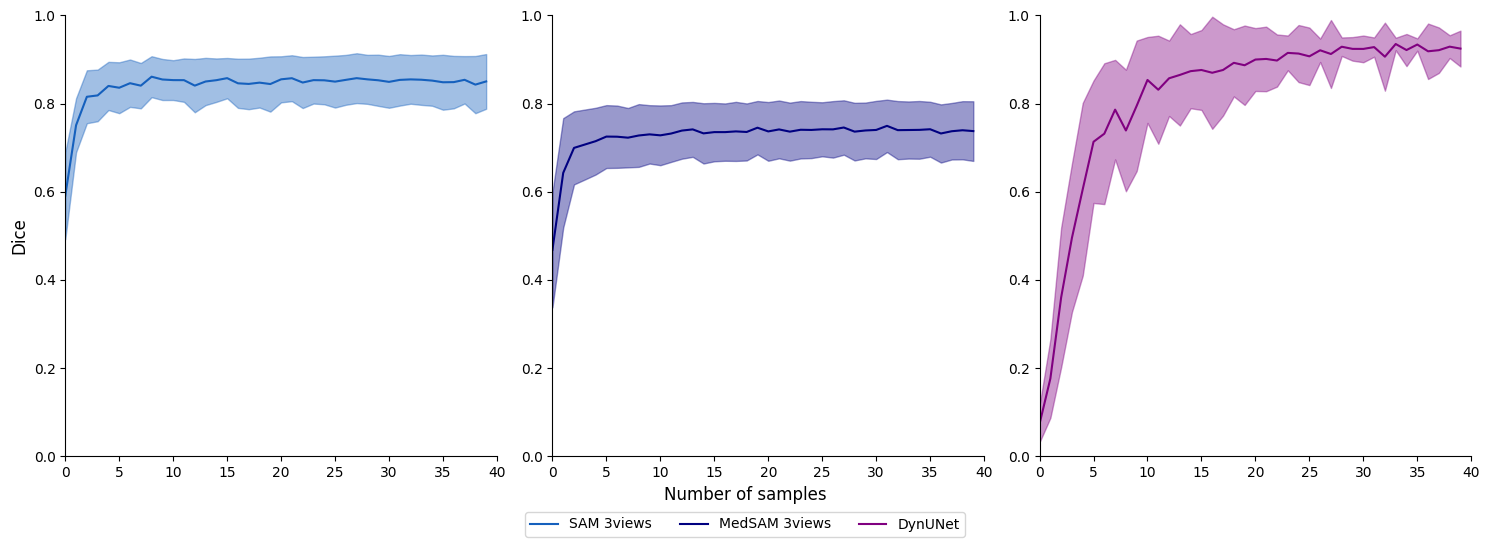

In [6]:
fig,ax = plt.subplots(1,3, figsize=(15,5))
# x_label = ['SAM 3views', 'MedSAM 3views', 'DynUNet']
# c1 = '#1560bd'
# c2 = '#bdd7e7'
# colors = get_color_gradient(c1, c2, len(x_labels))
colors = ['#1560bd', '#000080', '#800080']
ax[0].plot(avg_bbox_regression_sam_3views_dice_mean, label='SAM 3views', color=colors[0])
ax[0].fill_between(range(len(avg_bbox_regression_sam_3views_dice_mean)), avg_bbox_regression_sam_3views_dice_mean-avg_bbox_regression_sam_3views_dice_std, avg_bbox_regression_sam_3views_dice_mean+avg_bbox_regression_sam_3views_dice_std, alpha=0.4, color=colors[0])
# ax[0].legend()
ax[0].set_ylim(0, 1)
ax[0].set_xlim(1,40)
ax[0].set_xticks(range(0,41,5))
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].set_ylabel('Dice', fontsize=12)

ax[1].plot(avg_bbox_regression_medsam_3views_dice_mean, label='MedSAM 3views', color=colors[1])
ax[1].fill_between(range(len(avg_bbox_regression_medsam_3views_dice_mean)), avg_bbox_regression_medsam_3views_dice_mean-avg_bbox_regression_medsam_3views_dice_std, avg_bbox_regression_medsam_3views_dice_mean+avg_bbox_regression_medsam_3views_dice_std, alpha=0.4, color=colors[1])
# ax[1].legend()
ax[1].set_ylim(0, 1)
ax[1].set_xlim(1,40)
ax[1].set_xticks(range(0,41,5))
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

ax[2].plot(avg_dynunet_dice_mean, label='DynUNet', color=colors[2])
ax[2].fill_between(range(len(avg_dynunet_dice_mean)), avg_dynunet_dice_mean-avg_dynunet_dice_std, avg_dynunet_dice_mean+avg_dynunet_dice_std, alpha=0.4, color=colors[2])
# ax[2].legend()
ax[2].set_ylim(0, 1)
ax[2].set_xlim(1,40)
ax[2].set_xticks(range(0,41,5))
ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)

fig.text(0.5, -0.01, 'Number of samples', ha='center', fontsize=12)

plt.figlegend(loc='upper center', bbox_to_anchor=(0.5, -0.02),
          fancybox=True, shadow=False, ncol=3)


plt.tight_layout()
plt.savefig('figures/miccai2024/how_many_samples.pdf',bbox_inches='tight')

In [18]:
bbox_regression_sam_3views_dice.shape, bbox_regression_sam_3views_dice_mean.shape, bbox_regression_sam_3views_dice_mean[0].shape

((5, 40, 11), (40, 11), (11,))

In [17]:
np.argmax(avg_bbox_regression_medsam_3views_dice_mean), np.max(avg_bbox_regression_medsam_3views_dice_mean), np.argmax(avg_bbox_regression_sam_3views_dice_mean), np.max(avg_bbox_regression_sam_3views_dice_mean), np.argmax(avg_dynunet_dice_mean), np.max(avg_dynunet_dice_mean)

(31, 0.749491123809366, 31, 0.8873458109803508, 33, 0.9352086676007839)

/tmp/ipykernel_4068496/3609831990.py:28: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data, jitter=True, ax=ax, zorder=1, size=4, linewidth=0.1, color='black',edgecolor='gray')


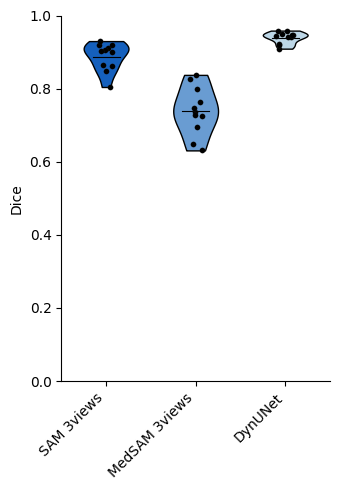

In [46]:
x_labels = ['SAM 3views', 'MedSAM 3views', 'DynUNet']
seed_index = 4
num = 39
data = [bbox_regression_sam_3views_dice[seed_index][num], bbox_regression_medsam_3views_dice, dynunet_dice[seed_index][num]]

c1 = '#1560bd'
c2 = '#bdd7e7'
colors = get_color_gradient(c1, c2, len(x_labels))
# colors = ['#1560bd','#000080', '#800080']
fig, ax = plt.subplots(1,1,figsize=(3.5,5))
plots = violinplot_with_mean_line(range(len(x_labels)), data, ax, colors, 1)


sns.stripplot(data, jitter=True, ax=ax, zorder=1, size=4, linewidth=0.1, color='black',edgecolor='gray')

ax.set_ylabel('Dice', fontsize=10)
ax.set_ylim(0, 1)
ax.set_xticks(np.arange(len(x_labels)), labels=x_labels)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation = 45, fontsize=10,ha='right')
plt.tight_layout()
plt.savefig(os.path.join('figures/miccai2024', '3views_vs_dynunet_seed2024_40samples.pdf'))

/tmp/ipykernel_4068496/894014882.py:14: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data, jitter=True, ax=ax, zorder=1, size=3, linewidth=0.1, color='black',edgecolor='gray')


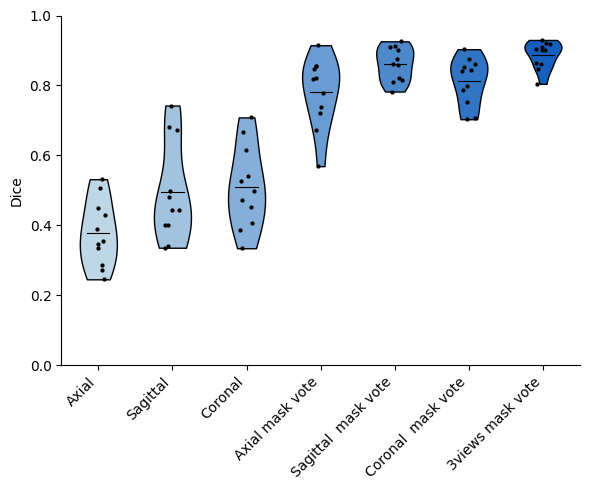

In [39]:
# majority vote comparision
x_labels = ['Axial', 'Sagittal', 'Coronal', 'Axial mask vote', 'Sagittal  mask vote', 'Coronal  mask vote', '3views mask vote']
seed_index = 4
num = 39
data = [ novote_sam_axial_dice[seed_index][num], novote_sam_sagittal_dice[seed_index][num], novote_sam_coronal_dice[seed_index][num], bbox_regression_sam_axial_dice[seed_index][num], bbox_regression_sam_sagittal_dice[seed_index][num], bbox_regression_sam_coronal_dice[seed_index][num], bbox_regression_sam_3views_dice[seed_index][num]]

c2 = '#1560bd'
c1 = '#bdd7e7'
colors = get_color_gradient(c1, c2, len(x_labels))
fig, ax = plt.subplots(1,1,figsize=(6,5))
plots = violinplot_with_mean_line(range(len(x_labels)), data, ax, colors, 1)


sns.stripplot(data, jitter=True, ax=ax, zorder=1, size=3, linewidth=0.1, color='black',edgecolor='gray')


ax.set_ylabel('Dice')
ax.set_ylim(0, 1)
ax.set_xticks(np.arange(len(x_labels)), labels=x_labels)
# ax.set_xlim(0.25, len(x_labels) + 0.75)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation = 45, fontsize=10,ha='right')
plt.tight_layout()
plt.savefig(os.path.join('figures/miccai2024', 'vote_vs_novote_seed2024_40samples.pdf'))

/tmp/ipykernel_728056/2696297837.py:16: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data, jitter=True, ax=ax, zorder=1, size=3, linewidth=0.1, color='black',edgecolor='gray')


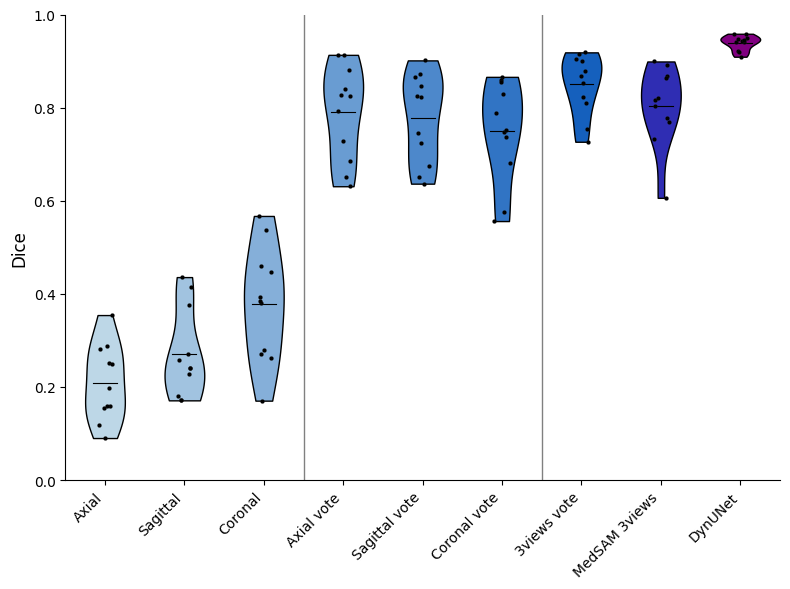

In [14]:
# majority vote comparision
x_labels = ['Axial', 'Sagittal', 'Coronal', 'Axial vote', 'Sagittal vote', 'Coronal vote', '3views vote', 'MedSAM 3views', 'DynUNet']
seed_index = 4
num = 39
data = [ novote_sam_axial_dice[seed_index][num], novote_sam_sagittal_dice[seed_index][num], novote_sam_coronal_dice[seed_index][num], bbox_regression_sam_axial_dice[seed_index][num], bbox_regression_sam_sagittal_dice[seed_index][num], bbox_regression_sam_coronal_dice[seed_index][num], bbox_regression_sam_3views_dice[seed_index][num], bbox_regression_medsam_3views_dice, dynunet_dice[seed_index][num]]

c2 = '#1560bd'
c1 = '#bdd7e7'
colors = get_color_gradient(c1, c2, 7)
colors.append('#2f2db3')
colors.append('#800080')
fig, ax = plt.subplots(1,1,figsize=(8,6))
plots = violinplot_with_mean_line(range(len(x_labels)), data, ax, colors, 1)


sns.stripplot(data, jitter=True, ax=ax, zorder=1, size=3, linewidth=0.1, color='black',edgecolor='gray')
ax.axvline(2.5, color='grey', lw=1)
ax.axvline(5.5, color='grey', lw=1)

ax.set_ylabel('Dice', fontsize=12)
ax.set_ylim(0, 1)
ax.set_xticks(np.arange(len(x_labels)), labels=x_labels)
# ax.set_xlim(0.25, len(x_labels) + 0.75)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation = 45, fontsize=10,ha='right')
plt.tight_layout()
plt.savefig(os.path.join('figures/miccai2024', 'all_3views_vs_medsamnorm_dynunet_seed2024_40samples.pdf'))

In [64]:
colors


['#bdd7e7', '#a1c3e0', '#85afd9', '#699cd2', '#4d88cb', '#3174c4', '#1560bd']